   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 16.8 MB/s eta 0:00:00
Mounted at /content/drive
Run: 20260306_125901
Rows: 100000


/tmp/ipykernel_157/2913300643.py:185: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


Notebook 01 Completed


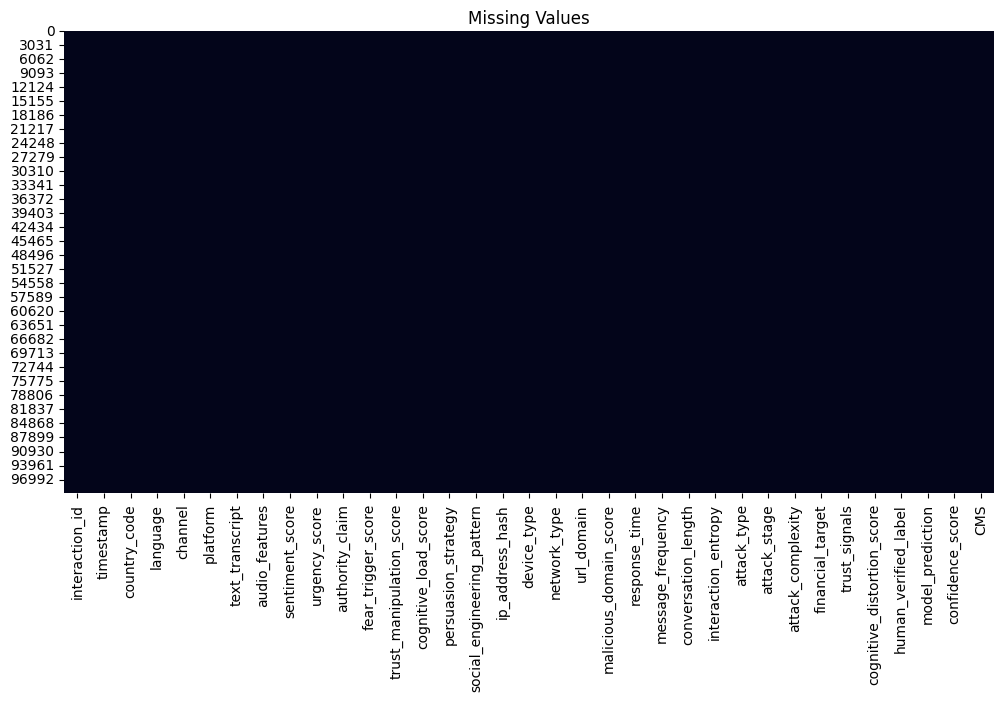

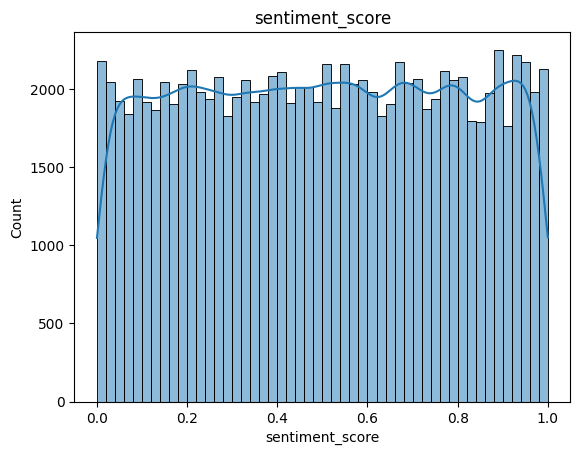

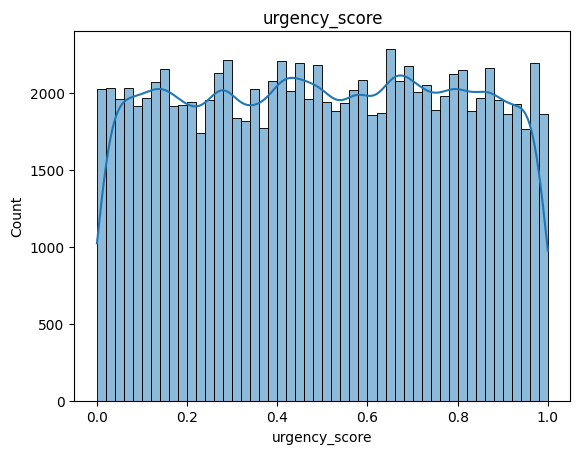

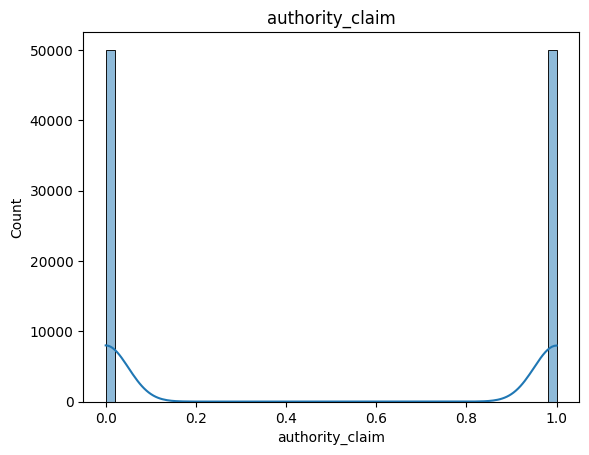

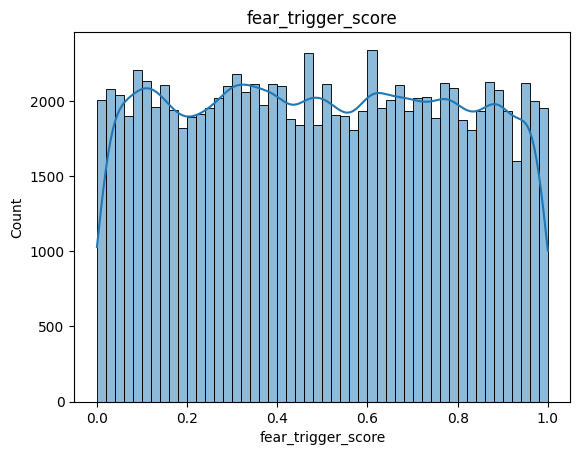

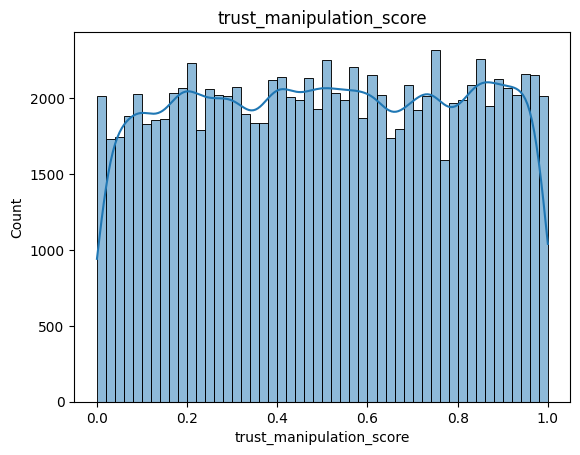

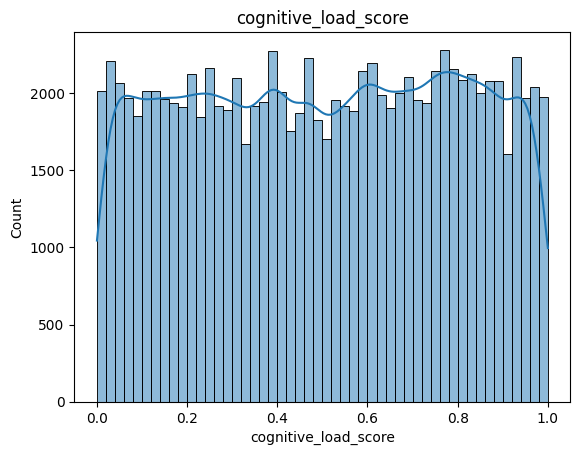

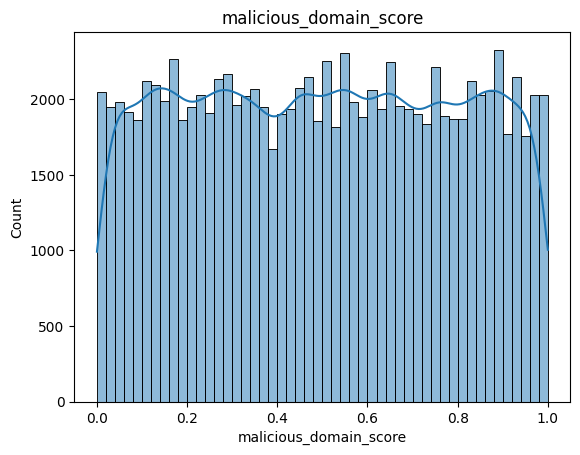

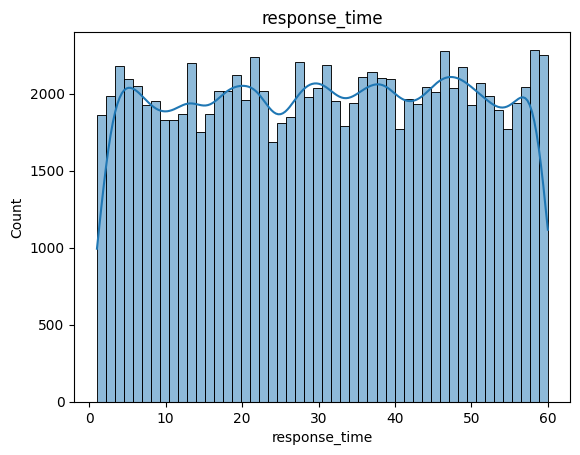

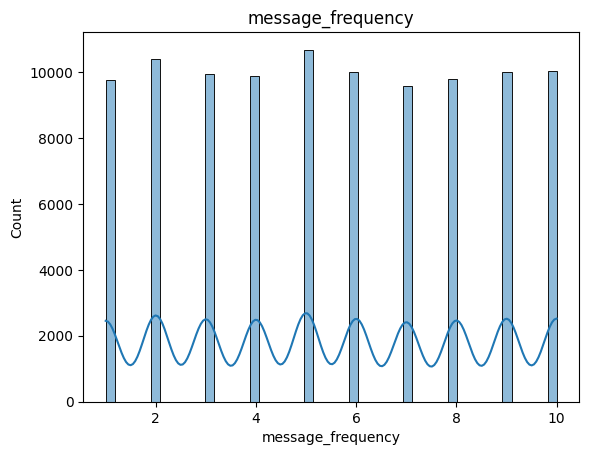

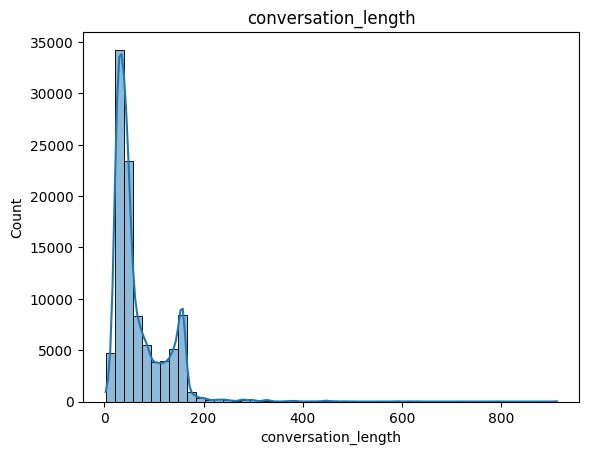

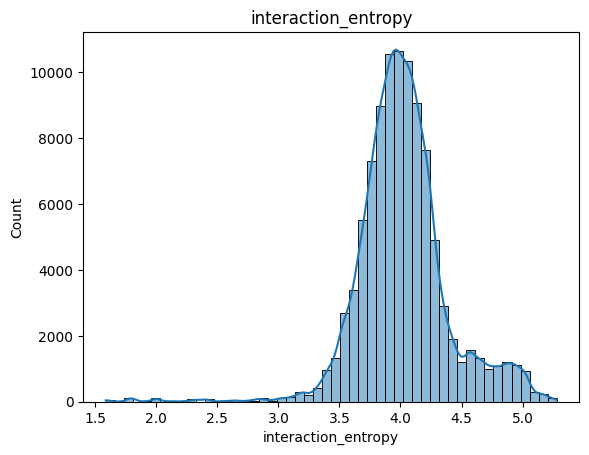

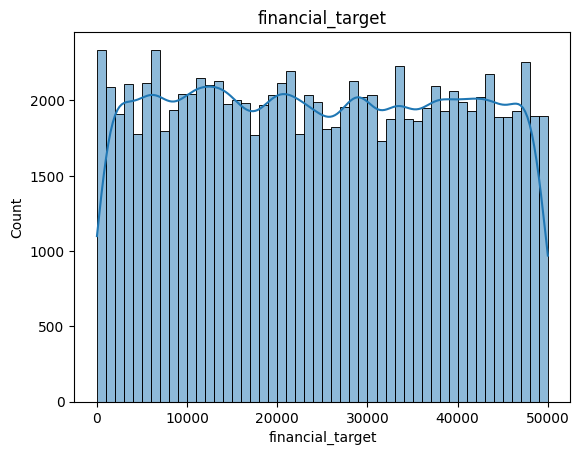

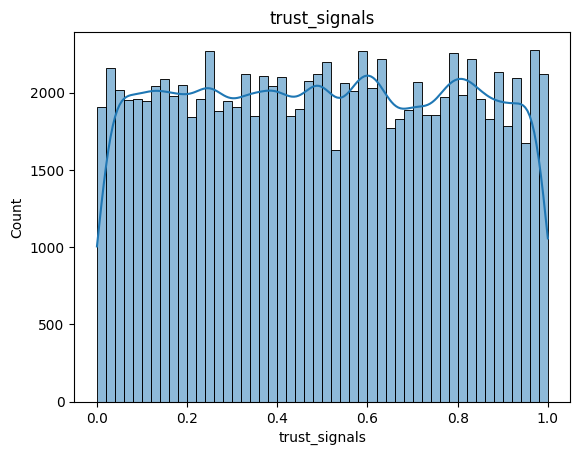

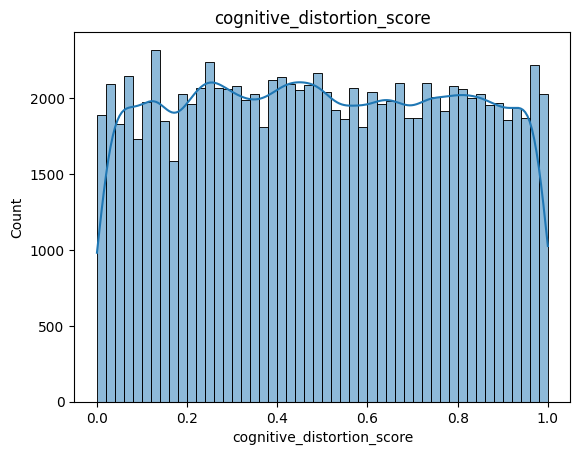

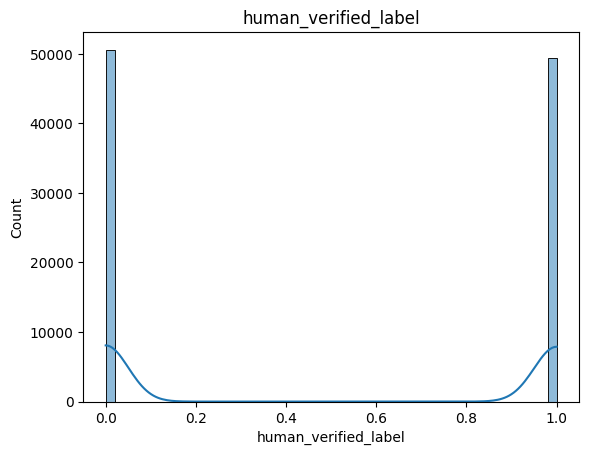

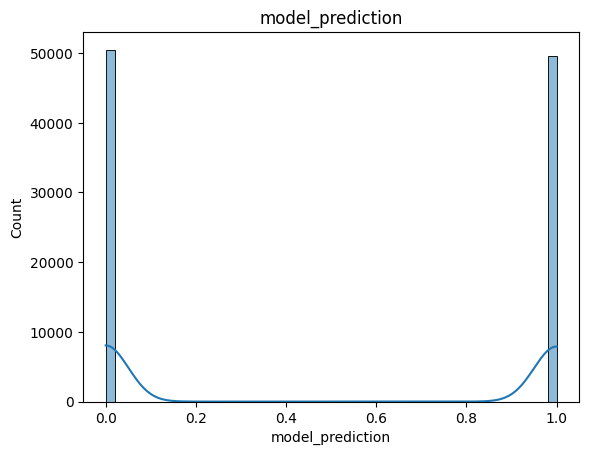

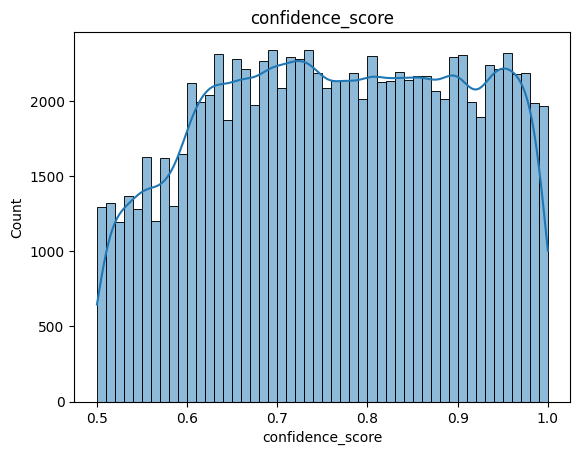

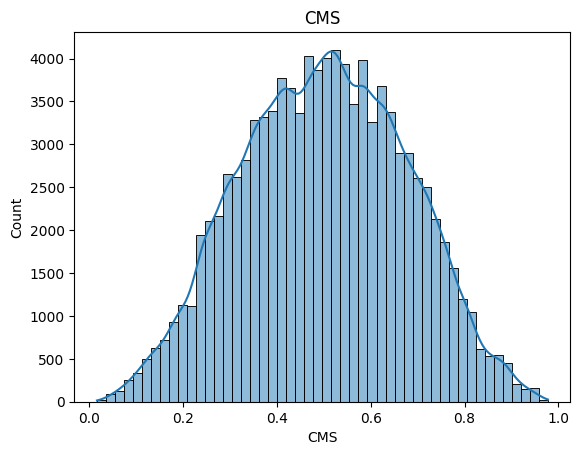

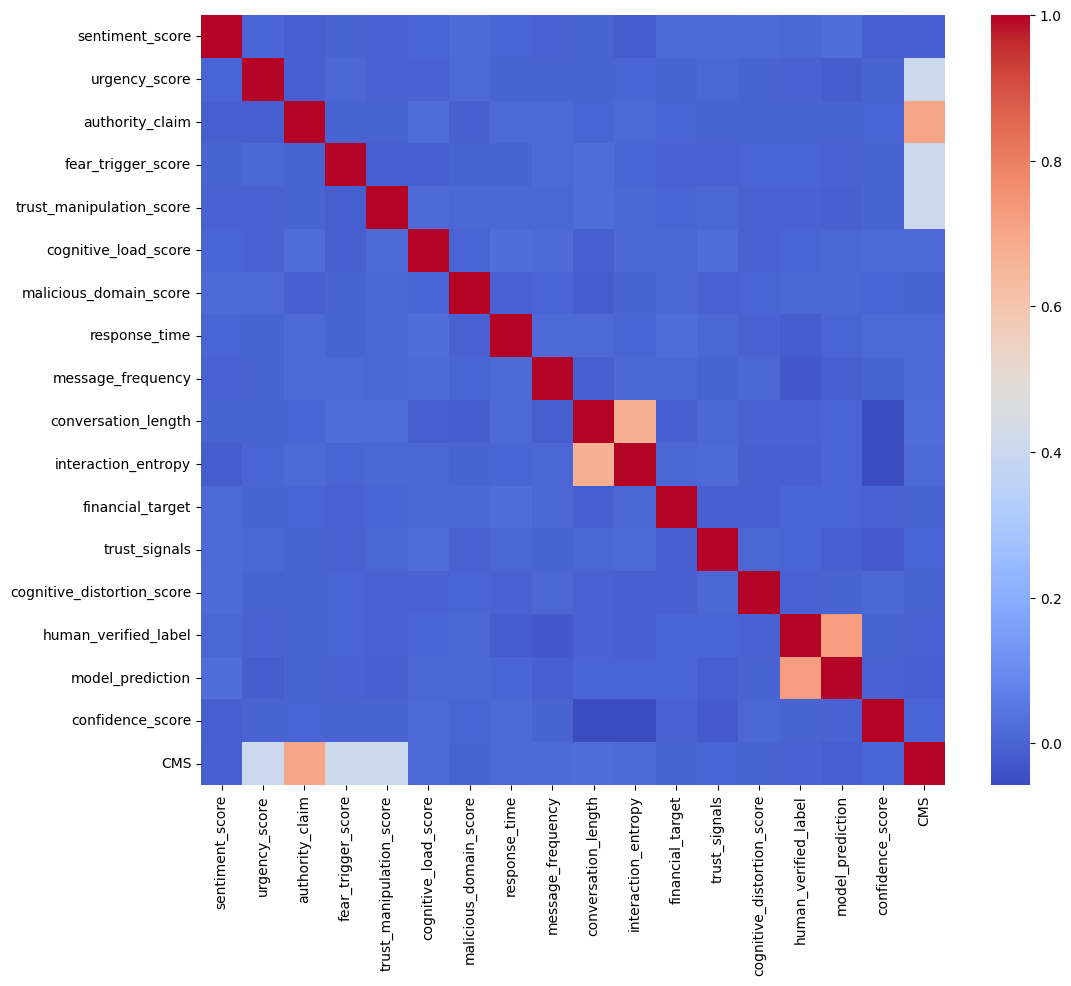

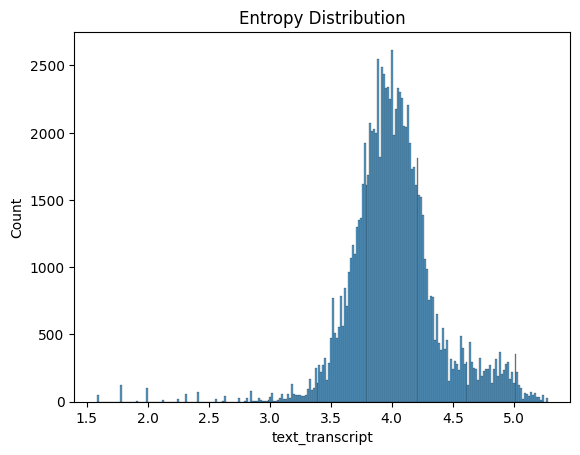

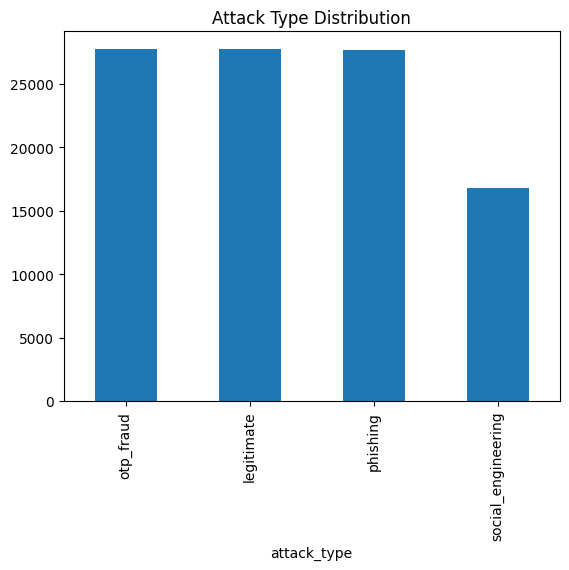

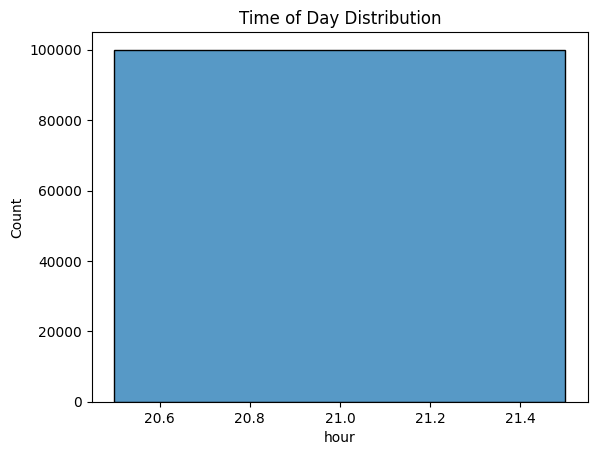

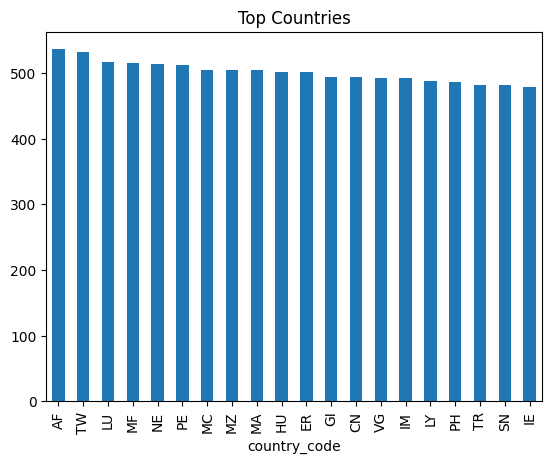

In [1]:
# ===============================================================
# NOTEBOOK 01 — CAT DATASET PROFILING
# Cognitive Attack Topology Framework
# ===============================================================

!pip -q install pandas numpy torch pyarrow seaborn matplotlib tqdm \
networkx scikit-learn pycountry psutil omegaconf

import os
import json
import uuid
import time
import torch
import psutil
import hashlib
import pycountry
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler

from google.colab import drive

# ===============================================================
# MOUNT DRIVE
# ===============================================================

drive.mount('/content/drive', force_remount=True)

ROOT = Path("/content/drive/MyDrive/CAT_RESEARCH")

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_DIR = ROOT/"runs"/RUN_ID
DATA_DIR = ROOT/"data"

REPORT_DIR = RUN_DIR/"reports"
PLOT_DIR = RUN_DIR/"plots"

for p in [RUN_DIR,REPORT_DIR,PLOT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Run:",RUN_ID)

# ===============================================================
# LOAD DATASET
# ===============================================================

DATA_PATH = DATA_DIR/"GCT_phase1_100k.parquet"

df = pd.read_parquet(DATA_PATH)

print("Rows:",len(df))

# ===============================================================
# CHECKSUM
# ===============================================================

with open(DATA_PATH,"rb") as f:
    checksum = hashlib.sha256(f.read()).hexdigest()

# ===============================================================
# UUID VALIDATION
# ===============================================================

uuid_valid = df["interaction_id"].apply(
    lambda x: isinstance(x,str) and len(x)==36
)

# ===============================================================
# TIMESTAMP VALIDATION
# ===============================================================

timestamps = pd.to_datetime(df["timestamp"],errors="coerce")

# ===============================================================
# COUNTRY CODE VALIDATION
# ===============================================================

iso = {c.alpha_2 for c in pycountry.countries}

invalid_country = df[~df["country_code"].isin(iso)]

# ===============================================================
# HASH VALIDATION
# ===============================================================

hash_valid = df["ip_address_hash"].str.len()==64

# ===============================================================
# MISSING DATA
# ===============================================================

missing = df.isnull().mean()*100
missing.to_csv(REPORT_DIR/"missing_value_report.csv")

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(),cbar=False)
plt.title("Missing Values")
plt.savefig(PLOT_DIR/"missing_heatmap.png")

# ===============================================================
# STATISTICS
# ===============================================================

num = df.select_dtypes(include=np.number)

stats = num.describe().T

stats.to_csv(REPORT_DIR/"dataset_statistics.csv")

# ===============================================================
# SKEWNESS / KURTOSIS
# ===============================================================

skew = num.skew()
kurt = num.kurtosis()

sk_df = pd.DataFrame({

"skewness":skew,
"kurtosis":kurt

})

sk_df.to_csv(REPORT_DIR/"feature_skewness_kurtosis.csv")

# ===============================================================
# HISTOGRAMS
# ===============================================================

for col in num.columns:

    plt.figure()

    sns.histplot(num[col],bins=50,kde=True)

    plt.title(col)

    plt.savefig(PLOT_DIR/f"hist_{col}.png")

# ===============================================================
# CORRELATION
# ===============================================================

corr = num.corr()

corr.to_csv(REPORT_DIR/"feature_correlation_matrix.csv")

plt.figure(figsize=(12,10))

sns.heatmap(corr,cmap="coolwarm")

plt.savefig(PLOT_DIR/"correlation_heatmap.png")

# ===============================================================
# ENTROPY VALIDATION
# ===============================================================

def entropy(text):

    probs = pd.Series(list(text)).value_counts(normalize=True)

    return -(probs*np.log2(probs)).sum()

entropy_recalc = df["text_transcript"].apply(entropy)

entropy_error = (entropy_recalc - df["interaction_entropy"]).abs()

entropy_report = pd.DataFrame({

"stored":df["interaction_entropy"],
"recomputed":entropy_recalc,
"error":entropy_error

})

entropy_report.to_csv(REPORT_DIR/"entropy_validation_report.csv")

plt.figure()

sns.histplot(entropy_recalc)

plt.title("Entropy Distribution")

plt.savefig(PLOT_DIR/"entropy_distribution.png")

# ===============================================================
# CLASS BALANCE
# ===============================================================

attack_dist = df["attack_type"].value_counts()

attack_dist.to_csv(REPORT_DIR/"class_balance_report.csv")

plt.figure()

attack_dist.plot(kind="bar")

plt.title("Attack Type Distribution")

plt.savefig(PLOT_DIR/"class_balance.png")

# ===============================================================
# FEATURE IMPORTANCE
# ===============================================================

if "human_verified_label" in df.columns:

    X = num.fillna(0)

    y = df["human_verified_label"]

    rf = RandomForestClassifier(n_estimators=200)

    rf.fit(X,y)

    imp = pd.DataFrame({

    "feature":X.columns,
    "importance":rf.feature_importances_

    }).sort_values("importance",ascending=False)

    imp.to_csv(REPORT_DIR/"feature_importance.csv")

# ===============================================================
# MUTUAL INFORMATION
# ===============================================================

mi = mutual_info_classif(X,y)

mi_df = pd.DataFrame({

"feature":X.columns,
"MI":mi

}).sort_values("MI",ascending=False)

mi_df.to_csv(REPORT_DIR/"mutual_information.csv")

# ===============================================================
# OUTLIER DETECTION
# ===============================================================

z_scores = (num - num.mean())/num.std()

outliers = (np.abs(z_scores)>3)

outlier_counts = outliers.sum()

outlier_counts.to_csv(REPORT_DIR/"outlier_detection_report.csv")

# ===============================================================
# TEMPORAL ANALYSIS
# ===============================================================

df["hour"] = timestamps.dt.hour

plt.figure()

sns.histplot(df["hour"])

plt.title("Time of Day Distribution")

plt.savefig(PLOT_DIR/"temporal_pattern.png")

# ===============================================================
# GEOGRAPHIC ANALYSIS
# ===============================================================

geo = df["country_code"].value_counts()

geo.to_csv(REPORT_DIR/"geo_distribution.csv")

plt.figure()

geo.head(20).plot(kind="bar")

plt.title("Top Countries")

plt.savefig(PLOT_DIR/"geo_distribution.png")

# ===============================================================
# PLATFORM ANALYSIS
# ===============================================================

platform = df["platform"].value_counts()

platform.to_csv(REPORT_DIR/"platform_distribution.csv")

# ===============================================================
# CMS VALIDATION
# ===============================================================

alpha=beta=gamma=delta=0.25

df["CMS_recalc"]=(
alpha*df["urgency_score"]+
beta*df["fear_trigger_score"]+
gamma*df["authority_claim"]+
delta*df["trust_manipulation_score"]
)

cms_error = (df["CMS"]-df["CMS_recalc"]).abs().mean()

# ===============================================================
# CAT TENSOR ENGINE
# ===============================================================

class TrustTensor:

    """
    T_{ijk} Trust Topology Tensor
    """

    def __init__(self, tensor):

        self.tensor = tensor

class CognitiveDistortionEnergy:

    """
    CDE = Σ ω_{ijk} T_{ijk}
    """

    def __init__(self, weights):

        self.weights = weights

    def __call__(self, T):

        return torch.einsum("ijk,ijk->",T.tensor,self.weights)

# ===============================================================
# GNN MESSAGE PASSING
# ===============================================================

class GraphWarpLayer:

    def __init__(self, in_dim,out_dim):

        self.W = torch.nn.Parameter(torch.randn(in_dim,out_dim))

    def __call__(self,H,A):

        return torch.einsum("ij,jk->ik",A,torch.einsum("ij,jk->ik",H,self.W))

# ===============================================================
# TDI SMOOTHING
# ===============================================================

class KalmanFilter:

    def __init__(self):

        self.x = 1
        self.P = 1
        self.Q = 1e-5
        self.R = 1e-2

    def update(self,z):

        K = self.P/(self.P+self.R)

        self.x = self.x + K*(z-self.x)

        self.P = (1-K)*self.P + self.Q

        return self.x

class TrustDistortionIndex:

    def __init__(self):

        self.filter = KalmanFilter()

    def __call__(self,cde,signals):

        var = torch.var(signals)

        smooth = self.filter.update(var.item())

        return cde/(smooth+1e-6)

# ===============================================================
# DEMO CAT COMPUTATION
# ===============================================================

users=64
channels=4
signals=8

T = torch.randn(users,channels,signals)

W = torch.randn(users,channels,signals)

tensor = TrustTensor(T)

cde_engine = CognitiveDistortionEnergy(W)

cde = cde_engine(tensor)

signals_vec = torch.randn(1000)

tdi_engine = TrustDistortionIndex()

tdi = tdi_engine(cde,signals_vec)

# ===============================================================
# FINAL REPORT
# ===============================================================

report = {

"rows":len(df),
"checksum":checksum,
"invalid_country_codes":len(invalid_country),
"uuid_valid_ratio":float(uuid_valid.mean()),
"cms_error":float(cms_error),
"CDE_demo":float(cde.item()),
"TDI_demo":float(tdi.item())

}

with open(REPORT_DIR/"dataset_report.json","w") as f:

    json.dump(report,f,indent=4)

print("Notebook 01 Completed")